# Classificação: Primeiros passos

Neste projeto, será analisado os dados de uma empresa de vendas de equipamentos industriais para análise de inadimplência. O intuito é analisar não o que foi pago, mas sim saber se os clientes continuaram atrasando os pagamentos, mesmo após a definição de pagamento em até 60 dias (2 meses).

Essa previsão será feita utilizando machine learning e este notebook vai conter os passos para se obter um modelo capaz de realizar as previsões, desde a **leitura**, **análise exploratória**, **separação** e **transformação** dos dados, até o **ajuste**, **avaliação** e **comparação** de modelos de classificação.

# Análise exploratória

## Fazendo a leitura dos dados

In [1]:
import pandas as pd

In [2]:
dados = pd.read_excel("faturamento_clientes.xlsx")

In [3]:
dados

,id_registro,cliente,valor_venda,tempo_faturamento_mes,inadimplencia,justificativa_atraso
0,1,Cliente 2,3585.528,2,nao,nao
1,2,Cliente 2,5763.488,3,sim,nao
2,3,Cliente 3,10489.592,3,sim,nao
3,4,Cliente 2,28129.968,3,sim,nao
4,5,Cliente 2,16549.152,2,nao,nao
...,...,...,...,...,...,...
1002,1003,Cliente 3,28058.344,3,sim,sim
1003,1004,Cliente 3,50708.584,4,sim,sim
1004,1005,Cliente 1,62666.232,1,nao,nao
1005,1006,Cliente 2,104623.912,3,sim,sim


Para criar modelos de classificação, deve ser utilizado dados de qualidade, sem inconsistências e sem dados faltantes. Checagem se existem dados nulos e o tipo dos dados de cada coluna na base de dados.

In [4]:
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 1007 entries, 0 to 1006
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_registro            1007 non-null   int64  
 1   cliente                1007 non-null   str    
 2   valor_venda            1007 non-null   float64
 3   tempo_faturamento_mes  1007 non-null   int64  
 4   inadimplencia          1007 non-null   str    
 5   justificativa_atraso   1007 non-null   str    
dtypes: float64(1), int64(2), str(3)
memory usage: 47.3 KB


## Explorando os dados

### Variáveis categóricas

In [5]:
import plotly.express as px

In [50]:
px.histogram(dados, x='inadimplencia', text_auto=True)

In [6]:
px.histogram(dados, x = 'cliente', text_auto=True, color = 'inadimplencia', barmode = 'group')

In [7]:
px.histogram(dados, x = 'cliente', text_auto=True, color = 'justificativa_atraso', barmode = 'group')

In [8]:
px.histogram(dados, x = 'cliente', text_auto=True, color = 'tempo_faturamento_mes', barmode = 'group')

In [9]:
px.box(dados, x = 'valor_venda', color = 'inadimplencia')

In [10]:
px.box(dados, x = 'valor_venda', color = 'tempo_faturamento_mes')

# Tranformação de dados

## Variáveis explicativas e variável alvo

Para fazer a previsão dos valores com um modelo de machine learning, precisa-se fazer a separação da variável alvo e variáveis explicativas. O y representa a variável que queremos prever, enquanto x representa todas as variáveis que serão utilizadas para explicar o comportamento de y.

In [11]:
dados

,id_registro,cliente,valor_venda,tempo_faturamento_mes,inadimplencia,justificativa_atraso
0,1,Cliente 2,3585.528,2,nao,nao
1,2,Cliente 2,5763.488,3,sim,nao
2,3,Cliente 3,10489.592,3,sim,nao
3,4,Cliente 2,28129.968,3,sim,nao
4,5,Cliente 2,16549.152,2,nao,nao
...,...,...,...,...,...,...
1002,1003,Cliente 3,28058.344,3,sim,sim
1003,1004,Cliente 3,50708.584,4,sim,sim
1004,1005,Cliente 1,62666.232,1,nao,nao
1005,1006,Cliente 2,104623.912,3,sim,sim


In [12]:
x = dados.drop(['inadimplencia'], axis = 1)
y = dados['inadimplencia']

In [13]:
x

,id_registro,cliente,valor_venda,tempo_faturamento_mes,justificativa_atraso
0,1,Cliente 2,3585.528,2,nao
1,2,Cliente 2,5763.488,3,nao
2,3,Cliente 3,10489.592,3,nao
3,4,Cliente 2,28129.968,3,nao
4,5,Cliente 2,16549.152,2,nao
...,...,...,...,...,...
1002,1003,Cliente 3,28058.344,3,sim
1003,1004,Cliente 3,50708.584,4,sim
1004,1005,Cliente 1,62666.232,1,nao
1005,1006,Cliente 2,104623.912,3,sim


In [14]:
y

0       nao
1       sim
2       sim
3       sim
4       nao
       ... 
1002    sim
1003    sim
1004    nao
1005    sim
1006    nao
Name: inadimplencia, Length: 1007, dtype: str

## Transformando as variáveis explicativas

Os algoritmos de machine learning não compreendem dados no formato de texto, portanto devemos fazer transformações nos dados para o formato numérico para que o algoritmo consiga compreender as informações. Essa transformação precisa ser feita de forma que não altere a informação original do conjunto de dados, portanto não basta simplesmente alterar os valores para valores numéricos aleatórios.

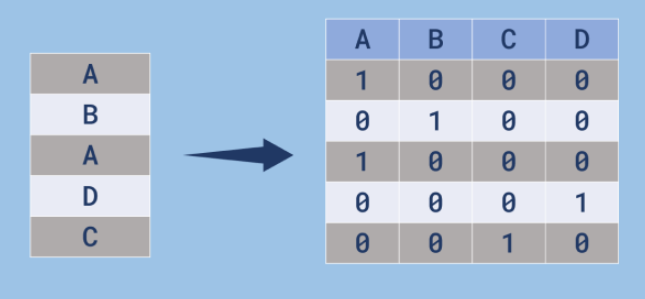

In [15]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [16]:
colunas = x.columns

In [17]:
one_hot = make_column_transformer((
    OneHotEncoder(drop = 'if_binary'),
    ['cliente', 'tempo_faturamento_mes', 'justificativa_atraso']
))

In [18]:
x = one_hot.fit_transform(x)

In [19]:
one_hot.get_feature_names_out(colunas)

array(['onehotencoder__cliente_Cliente 1',
       'onehotencoder__cliente_Cliente 2',
       'onehotencoder__cliente_Cliente 3',
       'onehotencoder__tempo_faturamento_mes_0',
       'onehotencoder__tempo_faturamento_mes_1',
       'onehotencoder__tempo_faturamento_mes_2',
       'onehotencoder__tempo_faturamento_mes_3',
       'onehotencoder__tempo_faturamento_mes_4',
       'onehotencoder__justificativa_atraso_sim'], dtype=object)

In [20]:
pd.DataFrame(x.toarray(), columns=one_hot.get_feature_names_out(colunas))

,onehotencoder__cliente_Cliente 1,onehotencoder__cliente_Cliente 2,onehotencoder__cliente_Cliente 3,onehotencoder__tempo_faturamento_mes_0,onehotencoder__tempo_faturamento_mes_1,onehotencoder__tempo_faturamento_mes_2,onehotencoder__tempo_faturamento_mes_3,onehotencoder__tempo_faturamento_mes_4,onehotencoder__justificativa_atraso_sim
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
1002,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
1003,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
1004,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1005,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


## Transformando a variável alvo

Assim como as variáveis explicativas, a variável alvo também precisa ser alterada para o formato numérico. Podemos representar uma variável alvo binária como 0 ou 1, onde 0 indica ausência da característica da variável e 1 representa a presença da característica.

In [21]:
from sklearn.preprocessing import LabelEncoder

In [22]:
label_ecoder = LabelEncoder()

In [23]:
y = label_ecoder.fit_transform(y)

In [24]:
y

array([0, 1, 1, ..., 0, 1, 0], shape=(1007,))

# Ajustando modelos

## Dividindo os dados entre treino e teste

Para compreender se o modelo está de fato aprendendo com os dados, precisamos fazer uma separação dos dados entre treinamento e teste. Os dados de **treinamento** são usados para ajustar o modelo, enquanto os dados de **teste** servem para verificar o aprendizado do modelo em dados que não foram utilizados no momento do ajuste.

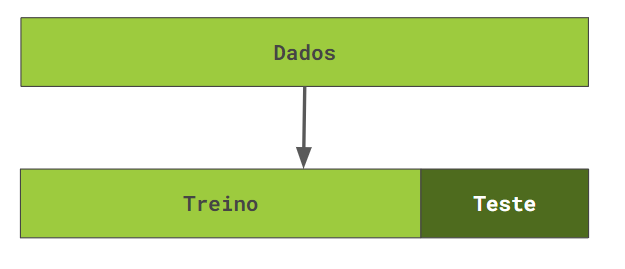

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, stratify = y,  random_state = 5)

## Modelo de base

O modelo mais simples de classificar os dados é simplesmente utilizar um algoritmo que chuta todas as classificações para a classe que tem maior frequência. Esse algoritmo serve como um critério de comparação, para identificar se os outros modelos tem um desempenho melhor do que a classificação mais simples possível.

In [27]:
from sklearn.dummy import DummyClassifier

In [28]:
dummy = DummyClassifier()
dummy.fit(x_treino, y_treino)

dummy.score(x_teste, y_teste)

0.6111111111111112

## Árvore de decisão

O modelo de árvore de decisão é muito utilizado pela sua alta **explicabilidade** e **processamento rápido**, mantendo um desempenho bem interessante.

Ele se baseia em decisões simples tomadas pelo algoritmo, separando os dados com base em comparações de **menor** e **maior** nos valores das colunas da base de dados.

In [29]:
from sklearn.tree import DecisionTreeClassifier

In [30]:
arvore = DecisionTreeClassifier(random_state =5)
arvore.fit(x_treino, y_treino)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",5
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [31]:
arvore.predict(x_teste)

array([0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1,
       1, 1, 0, 1, 0, 0, 0, 0, 1, 1])

Taxa de acerto do modelo

In [32]:
arvore.score(x_teste, y_teste)

1.0

In [33]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

In [34]:
nome_colunas = one_hot.get_feature_names_out(colunas)

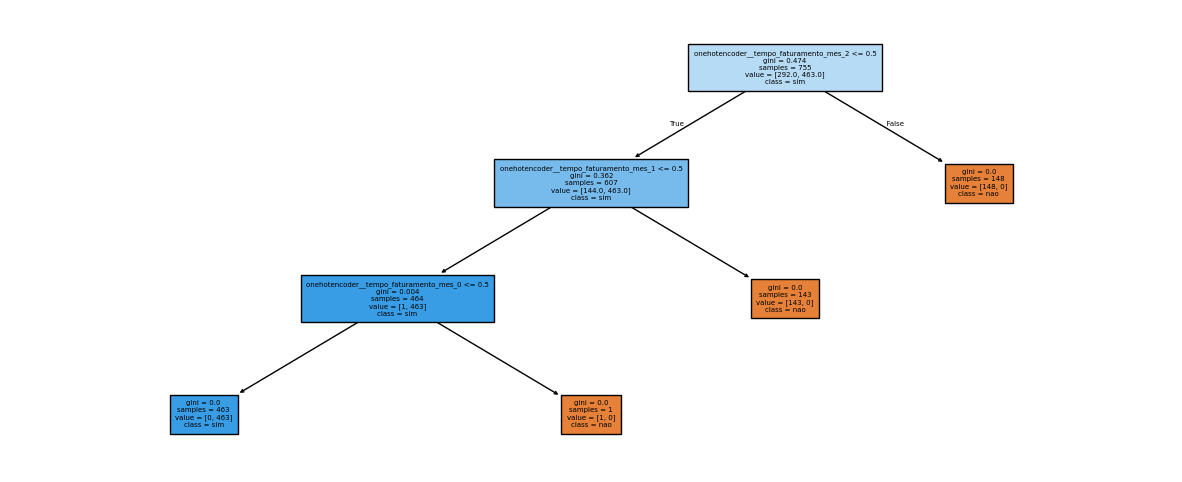

In [35]:
plt.figure(figsize = (15, 6))
plot_tree(arvore, filled = True, class_names = ['nao', 'sim'], fontsize = 5, feature_names = nome_colunas);

In [36]:
arvore.score(x_treino, y_treino)

1.0

In [37]:
arvore = DecisionTreeClassifier(max_depth = 1, random_state =5)
arvore.fit(x_treino, y_treino)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",5
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current nod

In [38]:
arvore.score(x_treino, y_treino)

0.8092715231788079

In [39]:
arvore.score(x_teste, y_teste)

0.8015873015873016

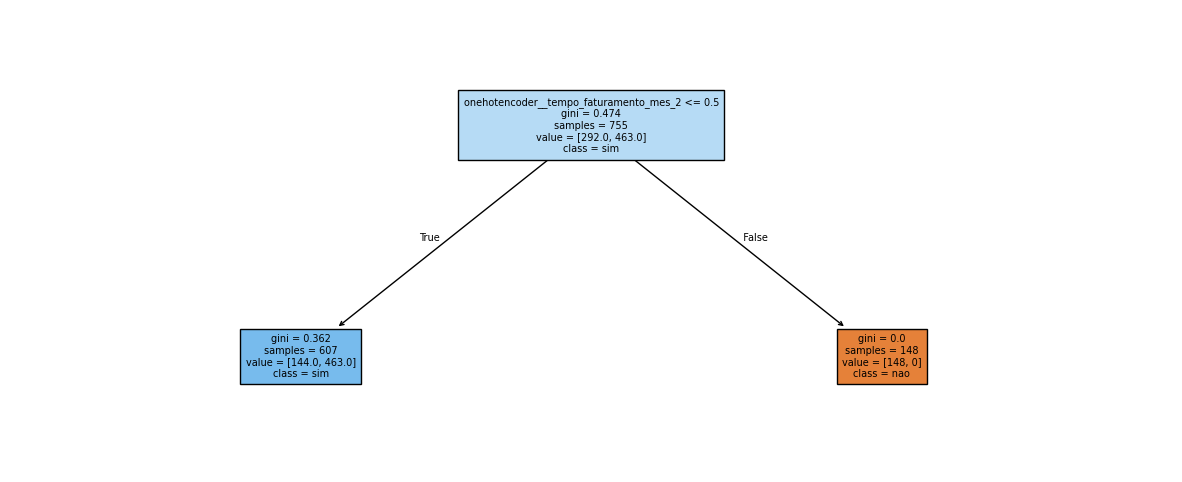

In [40]:
plt.figure(figsize = (15, 6))
plot_tree(arvore, filled = True, class_names = ['nao', 'sim'], fontsize = 7, feature_names = nome_colunas);

# Seleção de modelos

## Normalizando os dados

Alguns algoritmos podem atribuir um peso maior aos valores das variáveis devido a escala dos valores e não pela importância da classificação da variável alvo. Por exemplo, em uma base de dados com a colunas **idade** e **salário**, o algoritmo pode dar um peso de decisão maior para os valores do salário simplesmente por estar em uma escala maior do que os valores de idade, e não porque a variável salário é mais importante do que a variável idade.

Nesses casos, precisamos fazer uma transformação nos dados para que fiquem em uma mesma escala, fazendo com que o algoritmo não seja influenciado incorretamente pelos valores numéricos divergentes entre as variáveis.

$X_{sc} = \frac{X - X_{min}}{X_{max} - X_{min}} $

In [41]:
from sklearn.preprocessing import MinMaxScaler

In [42]:
from sklearn.preprocessing import MaxAbsScaler

normalizacao = MaxAbsScaler()
x_treino_normalizado = normalizacao.fit_transform(x_treino)

In [43]:
pd.DataFrame(x_treino_normalizado)

,0
0,<Compressed Sparse Row sparse matrix of dtype ...
1,<Compressed Sparse Row sparse matrix of dtype ...
2,<Compressed Sparse Row sparse matrix of dtype ...
3,<Compressed Sparse Row sparse matrix of dtype ...
4,<Compressed Sparse Row sparse matrix of dtype ...
...,...
750,<Compressed Sparse Row sparse matrix of dtype ...
751,<Compressed Sparse Row sparse matrix of dtype ...
752,<Compressed Sparse Row sparse matrix of dtype ...
753,<Compressed Sparse Row sparse matrix of dtype ...


## KNN

O algoritmo KNN se baseia no cálculo de distância entre os registros da base de dados e busca elementos que estejam próximos uns dos outros (vizinhos) para tomar a decisão da classificação.

Por conta de usar cálculos de distância, esse algoritmo é influenciado pela escala das variáveis e por conta disso é necessário uma transformação nos dados antes de utilizar esse método.

In [44]:
from sklearn.neighbors import KNeighborsClassifier

In [45]:
knn = KNeighborsClassifier()

In [46]:
knn.fit(x_treino_normalizado, y_treino)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [47]:
x_teste_normalizado = normalizacao.transform(x_teste)

O valor do resultado abaixo, mostra a avaliação de desempenho do teste

In [48]:
knn.score(x_teste_normalizado, y_teste)

1.0

## Escolhendo e salvando o melhor modelo

Ao final de um projeto de machine learning, devemos comparar os resultados dos modelos e escolher aquele que tenha o melhor desempenho.

In [49]:
print(f'Acurácia Dummy: {dummy.score(x_teste, y_teste):.4f}')
print(f'Acurácia Árvore: {arvore.score(x_teste, y_teste):.4f}')
print(f'Acurácia KNN: {knn.score(x_teste_normalizado, y_teste)}')

Acurácia Dummy: 0.6111
Acurácia Árvore: 0.8016
Acurácia KNN: 1.0
